### Simulating one EEG electrode for a single participant
- Simulating electrode Cz for a single participant
- Simulating a single electrode in the differing locations of the standard 64-channel montage

#### Imports

In [30]:
# Imports required for functionality 
# package that allows for EEG data simulation creation
!pip install mne 

import numpy as np

import mne

import matplotlib.pyplot as plt 

from specparam import SpectralModel

from neurodsp.sim import sim_oscillation
from neurodsp.plts import plot_time_series, plot_power_spectra

#### Simulating EEG data

In [16]:
# Simulation parameters
sfreq = 250  # Hz
duration = 10  # seconds
times = np.arange(0, duration, 1/sfreq)

# Simulate realistic EEG signal
alpha = 20e-6 * np.sin(2 * np.pi * 10 * times)  # 10 Hz alpha (20 µV)
noise = 5e-6 * np.random.randn(len(times))     # noise (5 µV)
signal = alpha + noise

data = signal[np.newaxis, :]  # shape (1, n_times)

# Create Info for Cz
info = mne.create_info(ch_names=["Cz"], sfreq=sfreq,ch_types=["eeg"])

# Load standard 64-channel BioSemi montage
montage = mne.channels.make_standard_montage("biosemi64")

# Attach montage to info
info.set_montage(montage)

# Create Raw object
raw = mne.io.RawArray(data, info)

Creating RawArray with float64 data, n_channels=1, n_times=2500
    Range : 0 ... 2499 =      0.000 ...     9.996 secs
Ready.


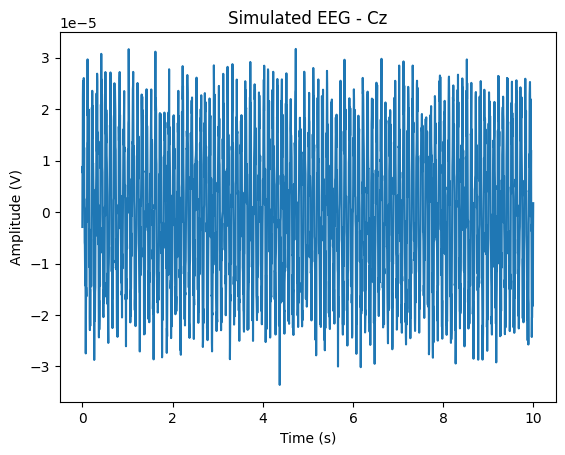

In [18]:
data, times = raw.get_data(return_times=True)

plt.figure()
plt.plot(times, data[0])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.title("Simulated EEG - Cz")
plt.show()

In [19]:
psd = raw.compute_psd(method="welch", fmin=1, fmax=40)
freqs = psd.freqs
power = psd.get_data()[0]

Effective window size : 8.192 (s)


In [27]:
## alt
# Simulation parameters
s_rate = 250  # Hz
duration = 10  # seconds
times = np.arange(0, duration, 1/s_rate)
freq = 10

# Simulate EEG-like signal 
signal = sim_oscillation(n_seconds=duration, fs=s_rate, freq=freq) 
signal *= 20e-6 #Scales to appropriate amplitude

# Add Gaussian noise
noise = 5e-6 * np.random.randn(len(signal))
EEG_signal = signal + noise

In [ ]:
# Plot time series
